In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import cfgrib

import utils
from package_name.evaluation import plots as eval_plots
from package_name.evaluation.utils import predict_clusters
from package_name.evaluation import metrics
from package_name.training.trainer import VAETrainer, VAEConfig
from package_name.training.finetuner import VAEFinetuner
from package_name.tuning.cross_validator import CrossValidator
from package_name.inference.predictor import VAEPredictor
from package_name.model.utils import sampling, LossFactorsConfig
from package_name.evaluation.pca_kmeans import PCAKmeansTrainer,  PCAKmeansPredictor

import matplotlib.pyplot as plt
plt.style.use('default')



/home/zilnora/.conda/envs/CodeForEarth/lib/python3.13/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
I0000 00:00:1787749785.193290 3418896 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787749785.194165 3418896 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787749785.256489 3418896 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787749789.817371 3418896 port.cc:153] oneDNN custom operations are on. You ma

## Parameters

In [2]:
g0 = 9.80665
extended_winter_months = [11, 12, 1, 2, 3]
results_path = "/net/nitrogen/atmosdyn/zilnora/code_for_earth/our_results/training_test_split/"
data_path = "/net/nitrogen/atmosdyn/zilnora/code_for_earth/our_data/wind/"
cluster_number = 4
original_dim = 575
pr_cluster_number = 4
batch_size = 128
epochs = 500

## Data loading and pre-processing

In [3]:
#create clusters for country-wise energy data
path = data_path + "WON_country_wise.csv"

df_in = pd.read_csv(path, comment="#")

df_filtered = df_in.copy()
df_filtered["Date"] = pd.to_datetime(df_filtered["Date"])
df_filtered = df_filtered[(df_filtered["Date"].dt.year > 1980) & (df_filtered["Date"].dt.year < 2023)]
df_filtered = df_filtered[df_filtered["Date"].dt.month.isin(extended_winter_months)]

df_countries = df_filtered.drop(columns=["Date"])
df_countries = df_countries.dropna(axis=1, how="all").reset_index(drop=True)

df_target, df_target_clusters = utils.cluster_country_wise(df_countries, cluster_number=pr_cluster_number, standardize=True)

#df_target_clusters.to_csv(data_path + "WON_clusters_norm.csv")
#df_target.to_csv(data_path + "WON_country_wise_norm.csv")

#df_target_clusters = pd.read_csv(data_path + "WON_clusters_norm.csv", index_col=0)
#df_target = pd.read_csv(data_path + "WON_country_wise_norm.csv", index_col=0)

In [5]:
# Get training data
z500 = utils.preprocess_dataset(filename = "/net/nitrogen/atmosdyn/zilnora/code_for_earth/our_data/z500/era5_z500_daily_250_atlantic_1940_2022.nc",
                             variable_name = 'z',
                             multiplication_factor = 1/g0,
                             geographical_filter = utils.GeographicalFilter.EXTENDED_EUROPE,
                             months_filter = extended_winter_months,
                             anomalies = True,
                             normalization = False,
                             rolling_window = 5)

z500 = z500.where(z500['time.year'] > 1980, drop=True)
z500 = z500.where(z500['time.year'] < 2023, drop=True)


weights = np.cos(np.deg2rad(z500.latitude))
z500 = z500*weights
std_dev = z500.std()
z500 = z500/z500.std()

z500_reshaped = utils.reshape_data_for_clustering(z500)


# Get training data labels
target_labels = pd.read_csv(data_path + 'WON_clusters_norm.csv')
target_labels.columns = ['index', 'labels']

target_labels['values']=[1]*len(target_labels)
target_categorical_pd = pd.pivot_table(target_labels, values='values', index=['index'],
                    columns=['labels'], aggfunc=np.sum).fillna(0)
target_categorical = target_categorical_pd.values



In [7]:
#set training and testing data
training_indices = np.where(z500['time.year'] < 2015)[0]
testing_indices = np.where(z500['time.year'] >= 2015)[0]

z500_training = z500[training_indices]
z500_testing = z500[testing_indices]

z500_reshaped_training = z500_reshaped[training_indices]
z500_reshaped_testing = z500_reshaped[testing_indices]

target_categorical_training = target_categorical[training_indices]
target_categorical_testing = target_categorical[testing_indices]

df_target_training = df_target.iloc[training_indices]
df_target_testing = df_target.iloc[testing_indices]

In [8]:
print("count of each label", target_categorical_training.sum(axis=0)/target_categorical_training.sum())

count of each label [0.23298327 0.38525865 0.16822248 0.21353559]


## Visualise target clusters

In [9]:
utils.plot_country_wise_cluster_means(country_data=df_target, cluster_labels=df_target_clusters)

## Define model (single run)

In [17]:
config = VAEConfig(
    original_dim=original_dim,
    original_dim_target=pr_cluster_number,
    dim_layer1=256,
    dim_layer2=128,
    dim_layer3=64,
    activation="relu",
    cluster_number=cluster_number,
    latent_dim=10,#8,
    pr_cluster_number=pr_cluster_number,
    sampling_fn=sampling,
)

loss_config = LossFactorsConfig(
    vae_reconstruction_loss_factor=1,
    vae_regularisation_loss_factor=1,
    target_prediction_loss_factor=1,
    cluster_target_regularisation_loss_factor=1,#5
    mixture_regularization_loss_factor=1,#2,
    dirichlet_loss_factor=0.5 #1
)

vae = VAETrainer(cfg=config,  path_to_save_weights=results_path, loss_factors=loss_config)
vae.compile()

history = vae.fit(
    X=z500_training.values,
    y=target_categorical_training,
    epochs=epochs,
    batch_size=batch_size
)

vae.save_weights(results_path+'final_weights_'+str(cluster_number)+'_4_5_training_test_500.weights.h5')

Epoch 1/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - cluster_target_regularisation_loss: 0.2408 - mixture_regularization_loss: 3.0233 - reconstruction_loss: 519.7114 - target_prediction_loss: 5.8511 - total_loss: 538.5177 - vae_regularisation_loss: 9.6911 - val_cluster_target_regularisation_loss: 0.4712 - val_mixture_regularization_loss: 3.0677 - val_reconstruction_loss: 393.4548 - val_target_prediction_loss: 7.2920 - val_total_loss: 427.8638 - val_vae_regularisation_loss: 23.5782
Epoch 2/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - cluster_target_regularisation_loss: 0.3740 - mixture_regularization_loss: 2.9415 - reconstruction_loss: 309.1168 - target_prediction_loss: 6.5143 - total_loss: 340.1214 - vae_regularisation_loss: 21.1748 - val_cluster_target_regularisation_loss: 0.3596 - val_mixture_regularization_loss: 2.9278 - val_reconstruction_loss: 246.6055 - val_target_prediction_loss: 6.1796 - val_total_loss: 275.2846 - val_vae_regularisation_loss: 19.2122
Epoch 3/500
29/29 ━━━━━━━

## Plot training and validation losses

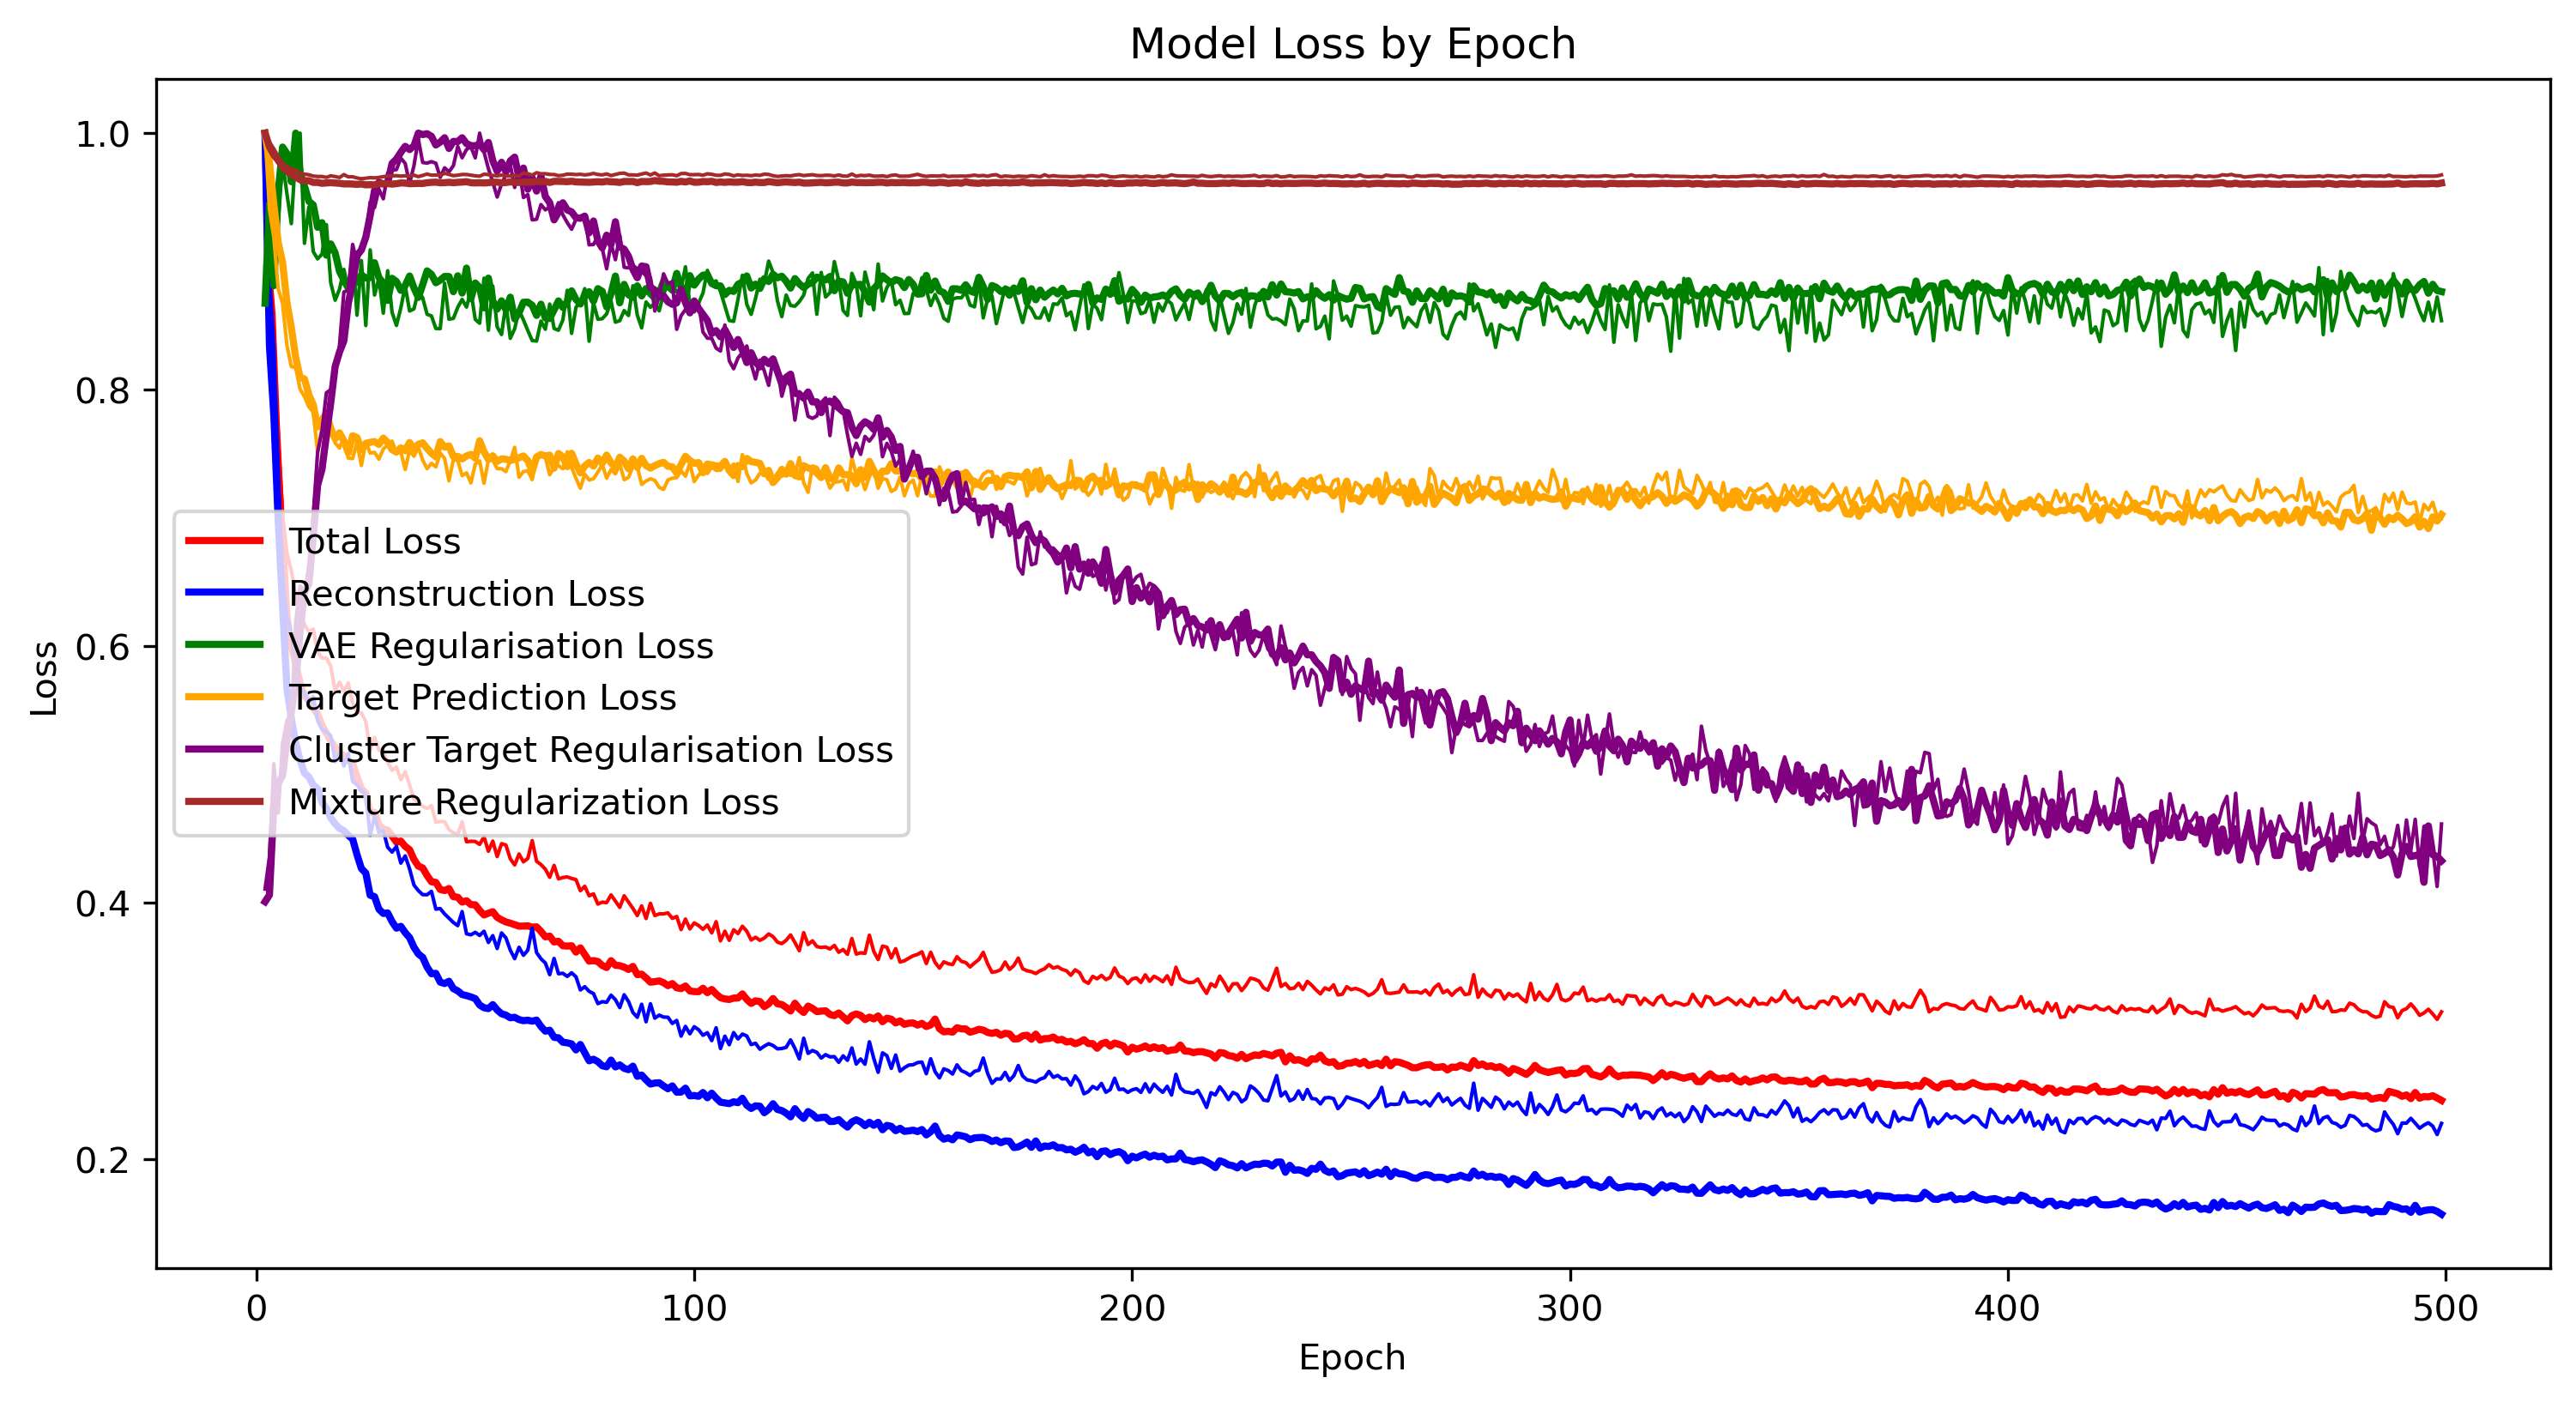

In [18]:
utils.plot_all_losses(history=history)

## Cross validation

In [52]:
cross_validator = CrossValidator(vae=vae,filepath=results_path,cluster_number=cluster_number,n_runs=10)
histories = cross_validator.run(X=z500_training.values,y=label_indices_training,epochs=epochs, batch_size=batch_size)

Epoch 1/500
 5/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - cluster_target_regularisation_loss: 0.2296 - mixture_regularization_loss: 3.7931 - reconstruction_loss: 575.6450 - target_prediction_loss: 6.6410 - total_loss: 594.4728 - vae_regularisation_loss: 8.1642 

10/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - cluster_target_regularisation_loss: 0.1853 - mixture_regularization_loss: 3.7133 - reconstruction_loss: 578.2624 - target_prediction_loss: 6.3928 - total_loss: 594.9443 - vae_regularisation_loss: 6.3905

/home/zilnora/.conda/envs/CodeForEarth/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 56 variables whereas the saved optimizer has 0 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - cluster_target_regularisation_loss: 0.2164 - mixture_regularization_loss: 3.3245 - reconstruction_loss: 513.5637 - target_prediction_loss: 5.9799 - total_loss: 533.3693 - vae_regularisation_loss: 10.2847 - val_cluster_target_regularisation_loss: 0.4676 - val_mixture_regularization_loss: 3.0587 - val_reconstruction_loss: 351.0237 - val_target_prediction_loss: 6.3800 - val_total_loss: 384.1212 - val_vae_regularisation_loss: 23.1912
Epoch 2/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - cluster_target_regularisation_loss: 0.4739 - mixture_regularization_loss: 2.9633 - reconstruction_loss: 272.7065 - target_prediction_loss: 6.4571 - total_loss: 306.1492 - vae_regularisation_loss: 23.5485 - val_cluster_target_regularisation_loss: 0.4288 - val_mixture_regularization_loss: 2.9058 - val_reconstruction_loss: 245.8583 - val_target_prediction_loss: 6.0162 - val_total_loss: 276.6445 - val_vae_regularisation_loss: 21.4355
Epoch 3/500
29/29 ━━━━━━━━━━━━━━━━━━

In [176]:
number = 0

training_loss = histories[number].history['total_loss']
validation_loss = histories[number].history['val_total_loss']
utils.plot_losses(training_loss, validation_loss)

NameError: name 'histories' is not defined